# Earbox ear trait analyser — headless reproduction (Phymea-Systems/Earbox)

**Paper:** "Earbox, an open tool for high-throughput measurement of the spatial organization of maize ears and inference of novel traits", *Plant Methods* 2022;18:96 (DOI 10.1186/s13007-022-00925-8).
**Code:** Phymea-Systems/Earbox @ commit `679dc6a4a335f113304e29e0fc0e6c6c29f0dc0d` (X11 licence). **Samples:** `analysis/segmentation/sample_data` ears `B1E10_1` and `13_29_WW_Hyb_08_46_c_1`.

**Scope (partial demonstration).** This notebook runs the authors' own MATLAB analyser (`FaceEarClass`, driven exactly like their `Utilities/Calculate_Ears.m`) **headless in GNU Octave** on a few repository sample ears, using the repository's **precomputed DL2 grain masks**. It computes ear axis length, maximum diameter, grains per row, ring (cohort) counts, and fertile/apical/basal zone lengths, per imaged face. It does **not** retrain or re-run the Mask-RCNN (the trained `.h5` weights are not public), does not reproduce the acquisition hardware, and does not validate against the paper's 791-ear dataset (available from the authors on request).

**日本語:** 著者自身のMATLAB解析コード(`FaceEarClass`)をGNU Octaveでヘッドレス実行し、リポジトリ公開のサンプル穂と事前計算済みDL2粒マスクから、穂長・最大径・1列当たり粒数・ring数・可育/敗育 zones を計算します。CNNの再学習・再推論は行いません(学習済み重みは非公開)。**実行環境の選択:** このノートブックは **CPU ランタイムのみ** を使用します(GPU不要)。Run all で数分で完了します。

**Execution status:** executed and validated in a fresh Colab CPU runtime (see final outputs). Author code executed unmodified except for the documented compatibility patches listed below and inside the notebook.


## Runtime selection

**Select a CPU runtime** (Runtime → Change runtime type → CPU). No GPU is used: the analysis is classical image processing on ~0.5–1.5 MP crops and the deep segmentation is already precomputed. Expected wall time: ~4–8 minutes total (Octave install ≈ 2–4 min, downloads ≈ 10 MB, analysis seconds per ear face).
日本語: CPU ランタイムを選択してください。GPUは不要です。全体で数分で終わります。

**Install GNU Octave and the image package.** This provides a MATLAB-language interpreter for the authors' `.m` code. Expected: Octave 8.x and `pkg load image` succeed.
日本語: 著者コードを実行するため GNU Octave と image パッケージを導入します。

In [ ]:
import subprocess
r = subprocess.run("apt-get update -qq && apt-get install -y -qq octave octave-image",
                   shell=True)
assert r.returncode == 0, "apt-get install failed"
v = subprocess.run(["octave", "--no-gui", "--eval", "disp(version); pkg load image; disp('image pkg OK')"],
                   capture_output=True, text=True)
print(v.stdout[-500:], v.stderr[-500:])
assert "image pkg OK" in v.stdout

8.4.0
image pkg OK
 octave: X11 DISPLAY environment variable not set
octave: disabling GUI features



**Fetch the pinned author code and two sample ears (inside Colab only).** We download exactly the analyser `.m` files and, for ears `B1E10_1` (biological-diversity panel) and `13_29_WW_Hyb_08_46_c_1` (well-watered hybrid), the RGB image, IR image and precomputed DL2 grain mask from the pinned commit. Byte counts are printed for provenance.
日本語: ピン留めしたコミットから解析コードと2穂分のRGB/IR/DL2マスクをColab内へ取得します(DGX等へは保存しません)。

In [ ]:
import urllib.request, urllib.parse, pathlib
ROOT = pathlib.Path("/content/earbox"); (ROOT / "code").mkdir(parents=True, exist_ok=True)
COMMIT = "679dc6a4a335f113304e29e0fc0e6c6c29f0dc0d"
CODE_FILES = ['analysis/matlab-analyser/@FaceEarClass/FaceEarClass.m', 'analysis/matlab-analyser/@FaceEarClass/ringCount.m', 'analysis/matlab-analyser/@FaceEarClass/horizontalFileDetection.m', 'analysis/matlab-analyser/@FaceEarClass/verticalFileDetection.m', 'analysis/matlab-analyser/@FaceEarClass/resizeProps.m', 'analysis/matlab-analyser/@FaceEarClass/refineSegmentation.m', 'analysis/matlab-analyser/@FaceEarClass/refineSegmentation_Old.m', 'analysis/matlab-analyser/Utilities/imcbr.m', 'analysis/matlab-analyser/Utilities/imobr.m', 'analysis/matlab-analyser/Utilities/imcbrobr.m', 'analysis/matlab-analyser/Utilities/imobrcbr.m', 'analysis/matlab-analyser/Utilities/otsu.m', 'analysis/matlab-analyser/Utilities/circularity.m']
SAMPLES = {'B1E10_1': ['RGB.png', 'IR.png', 'DL2_mask.png'], '13_29_WW_Hyb_08_46_c_1': ['RGB.png', 'IR.png', 'DL2_mask.png']}
def fetch(rel, dest):
    url = "https://raw.githubusercontent.com/Phymea-Systems/Earbox/{}/{}".format(COMMIT, urllib.parse.quote(rel))
    data = urllib.request.urlopen(url, timeout=60).read()
    path = ROOT / dest; path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(data); print(len(data), dest)
for rel in CODE_FILES:
    fetch(rel, "code/" + rel)
for ear, files in SAMPLES.items():
    for name in files:
        fetch("analysis/segmentation/sample_data/" + ear + "/" + name, "sample/" + ear + "/" + name)
print("done")

90709 code/analysis/matlab-analyser/@FaceEarClass/FaceEarClass.m
3124 code/analysis/matlab-analyser/@FaceEarClass/ringCount.m


6245 code/analysis/matlab-analyser/@FaceEarClass/horizontalFileDetection.m
8715 code/analysis/matlab-analyser/@FaceEarClass/verticalFileDetection.m


9077 code/analysis/matlab-analyser/@FaceEarClass/resizeProps.m


13446 code/analysis/matlab-analyser/@FaceEarClass/refineSegmentation.m
9826 code/analysis/matlab-analyser/@FaceEarClass/refineSegmentation_Old.m


271 code/analysis/matlab-analyser/Utilities/imcbr.m
259 code/analysis/matlab-analyser/Utilities/imobr.m


...

412264 sample/B1E10_1/RGB.png


333965 sample/B1E10_1/IR.png
18216 sample/B1E10_1/DL2_mask.png


956850 sample/13_29_WW_Hyb_08_46_c_1/RGB.png


826996 sample/13_29_WW_Hyb_08_46_c_1/IR.png


25982 sample/13_29_WW_Hyb_08_46_c_1/DL2_mask.png
done


**Build the analyser's expected `data/<ear>/<face>/` layout.** The analyser reads `RGB.png`, `IR.png` and an ear-silhouette mask `ROI.png` from `data/<code>/<face>/`, and the DL grain mask from a separate folder. The sample data provide no `ROI.png`, but per `ear_masking/writeEarImages.m` the stored crops are `crop .* ROI` padded by 50 px, so the silhouette is faithfully recoverable as `RGB > 0`, opened with a disk(10) exactly as in `writeEarImages`. The DL2 masks are staged as `<code>_<face>.png` for the (patched) `readImage('A')`.
日本語: 解析器が期待するフォルダ構成を作ります。`ROI.png` は `writeEarImages.m` の仕様から `RGB>0` を disk(10) でオープニングして再構築します。

In [ ]:
import numpy as np
from PIL import Image
import shutil, pathlib
from scipy import ndimage
ROOT = pathlib.Path("/content/earbox")
for ear in SAMPLES:
    face_dir = ROOT / "data" / ear / "1"; face_dir.mkdir(parents=True, exist_ok=True)
    rgb = np.array(Image.open(ROOT / "sample" / ear / "RGB.png").convert("RGB"))
    ir = np.array(Image.open(ROOT / "sample" / ear / "IR.png").convert("RGB"))
    dl = np.array(Image.open(ROOT / "sample" / ear / "DL2_mask.png"))
    assert rgb.shape == ir.shape and dl.shape == rgb.shape[:2], (rgb.shape, ir.shape, dl.shape)
    roi = (rgb.max(axis=2) > 0)
    st = np.zeros((21, 21), bool)
    yy, xx = np.mgrid[-10:11, -10:11]
    st[yy**2 + xx**2 <= 100] = True
    roi = ndimage.binary_opening(roi, structure=st)
    Image.fromarray(roi.astype(np.uint8) * 255).save(face_dir / "ROI.png")
    shutil.copy(ROOT / "sample" / ear / "RGB.png", face_dir / "RGB.png")
    shutil.copy(ROOT / "sample" / ear / "IR.png", face_dir / "IR.png")
    dl_out = ROOT / "dlout"; dl_out.mkdir(exist_ok=True)
    Image.fromarray(dl).save(dl_out / (ear + "_1.png"))
    print(ear, "RGB", rgb.shape, "DL2 grains:", int((dl > 0).sum()))

B1E10_1 RGB (520, 925, 3) DL2 grains: 163939


13_29_WW_Hyb_08_46_c_1 RGB (581, 1649, 3) DL2 grains: 466006


**Input preview — original ear image with the reference DL2 grain mask overlay.** Red contours are the authors' precomputed DL2 Mask-RCNN grain segmentation shipped in the repository (reference annotation, not a result of this notebook). This is the actual input handled by the reproduction.
日本語: 元画像(上段)と、リポジトリ同梱のDL2粒マスク(赤輪郭)を重畳した表示です。

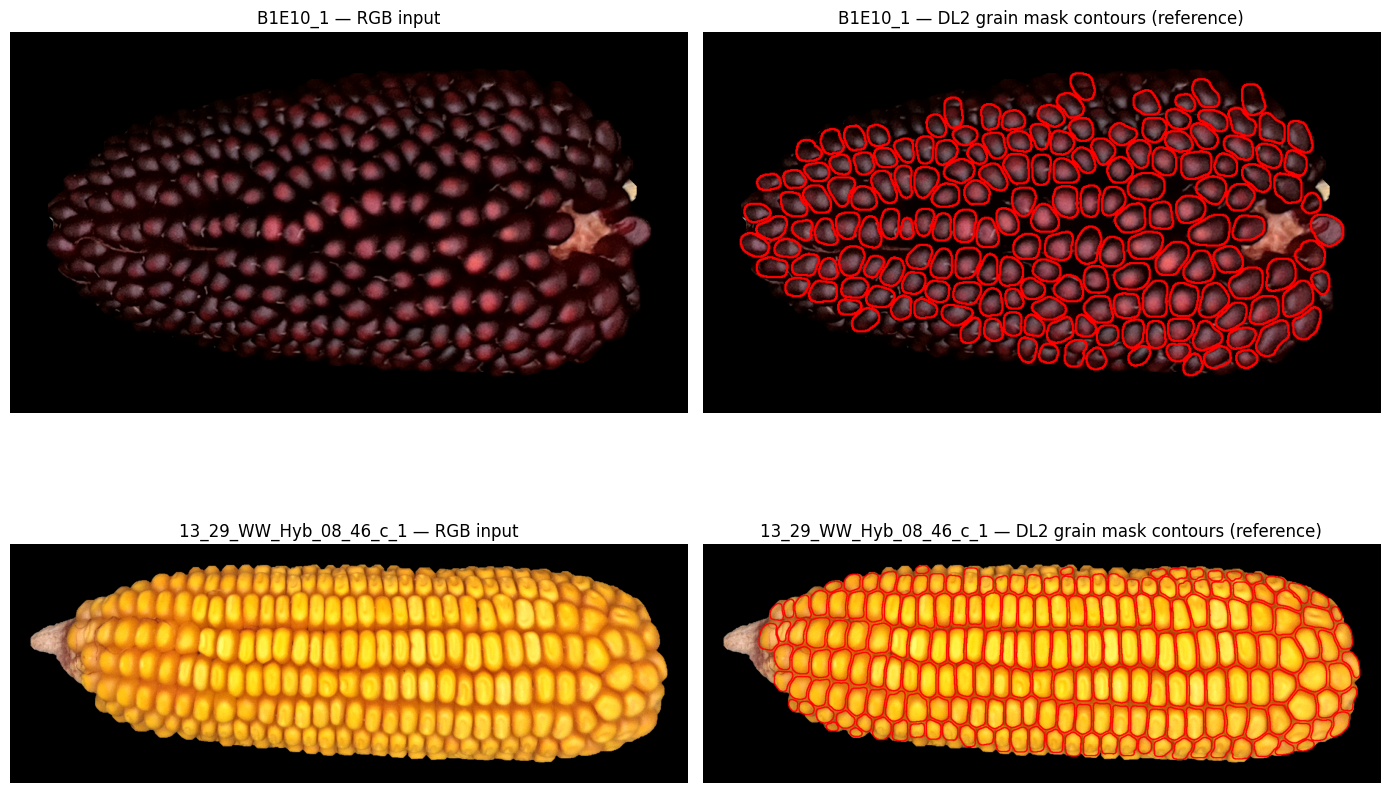

In [ ]:
import numpy as np, cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/content/earbox")
fig, axes = plt.subplots(len(SAMPLES), 2, figsize=(14, 5 * len(SAMPLES)))
for row, ear in enumerate(SAMPLES):
    rgb = np.array(Image.open(ROOT / "sample" / ear / "RGB.png").convert("RGB"))
    dl = (np.array(Image.open(ROOT / "sample" / ear / "DL2_mask.png")) > 0).astype(np.uint8)
    overlay = rgb.copy()
    cnts, _ = cv2.findContours(dl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cnts, -1, (255, 0, 0), 2)
    axes[row, 0].imshow(rgb); axes[row, 0].set_title(ear + " — RGB input"); axes[row, 0].axis("off")
    axes[row, 1].imshow(overlay); axes[row, 1].set_title(ear + " — DL2 grain mask contours (reference)"); axes[row, 1].axis("off")
plt.tight_layout(); plt.savefig("/content/earbox/inputs_preview.png", dpi=110); plt.show()

**Compatibility patches (all documented, minimal).** The authors' code is otherwise executed unmodified in Octave. Five adaptations are required and applied here:
1. `readImage('A')` contains a hardcoded Windows path `E:\...` for the DL mask folder → replaced by `/content/earbox/dlout`.
2. Three GUI-figure helper methods (`saveHorzFileImage`, `saveVertFileImage`, `showAndSaveResultsImage`) do not parse under Octave → stubbed; they only produce optional figures.
3. `strel('disk', r)` uses MATLAB's N=4 disk approximation; Octave only implements the exact disk (N=0) → all disk strels use N=0.
4. Octave's `bwmorph(v,'shrink',inf)` on a row vector pads to a square (verified in a probe) → replaced by an equivalent 1-D run-to-centre reduction `row_shrink`.
5. Small shims for `round(x,n)` (digits argument) and `smooth` (moving average) which Octave lacks.
日本語: Octave互換のための最小限のパッチ(パス置換、GUI図関数のスタブ化、strel disk N=0、行ベクトルshrink、round/smooth代替)を適用します。著者のアルゴリズム本体は無変更です。

In [ ]:
import pathlib, re
ROOT = pathlib.Path("/content/earbox")
cls = ROOT / "code" / "analysis" / "matlab-analyser" / "@FaceEarClass" / "FaceEarClass.m"
src = cls.read_bytes().decode("latin-1")
old = "PathToRefined = 'E:\\Phymea\\EarBox\\Deep Learning\\Outputs\\EarCode_Side.png';"
assert old in src, "path literal not found"
src = src.replace(old, "PathToRefined = '/content/earbox/dlout';")
def _stub(text, sig, outvar):
    L = text.split(chr(10))
    i = next(k for k, l in enumerate(L) if l.startswith(sig))
    j = next(k for k in range(i + 1, len(L)) if L[k].startswith("        function") or L[k] == "    end")
    new = [sig, "            % visualization omitted in headless reproduction", "            " + outvar + " = [];", "        end"]
    return chr(10).join(L[:i] + new + L[j:])
src = _stub(src, "        function HorzFileImage = saveHorzFileImage(obj,visibility)", "HorzFileImage")
src = _stub(src, "        function VertFileImage=saveVertFileImage(obj,visibility)", "VertFileImage")
src = _stub(src, "        function ResultsImage = showAndSaveResultsImage(obj,EarLengthHalfImage,FigLength,Visibility,Save,EarMask,ColorMask)", "ResultsImage")
src = re.sub(r"strel\('disk',\s*([0-9]+)\)", lambda m: "strel('disk', " + m.group(1) + ", 0)", src)
src = src.replace("shrinkifyy(i,:) = bwmorph(vecty,'shrink',inf);",
                  "shrinkifyy(i,:) = row_shrink(vecty);  % Octave: 1-D equivalent of bwmorph 'shrink'")
src = src.replace("properties (Dependent, Transient)", "properties")  # Octave lacks Transient attribute
src = src.replace("properties (Transient)", "properties")
src = re.sub(r"^\s*output = (refineSegmentation|refineSegmentation_Old|resizeProps|horizontalFileDetection|verticalFileDetection|ringCount)\(obj\)\s*$",
             "% method defined in separate @class file", src, flags=re.M)
cls.write_bytes(src.encode("latin-1"))
stale = ROOT / "code" / "analysis" / "matlab-analyser" / "FaceEarClass.m"
if stale.exists(): stale.unlink()
shims = ROOT / "shims"; shims.mkdir(exist_ok=True)
for name, body in {
  "round.m": ["function y = round(x, varargin)", "  if nargin < 2", "    y = builtin('round', x);", "  else", "    f = 10 .^ varargin{1};", "    y = builtin('round', x .* f) ./ f;", "  end", "end"],
  "medfilt1.m": ["function y = medfilt1(x, k)", "  x = double(x(:)); pad = floor(k/2);", "  xp = [repmat(x(1), pad, 1); x; repmat(x(end), pad, 1)];", "  y = zeros(length(x), 1);", "  for i = 1:length(x)", "    y(i) = median(xp(i:i+k-1));", "  end", "  y = reshape(y, 1, []);", "end"],
  "smooth.m": ["function y = smooth(x, span)", "  x = double(x(:)); span = max(1, round(span));", "  kernel = ones(span, 1) / span;", "  xp = [repmat(x(1), span, 1); x; repmat(x(end), span, 1)];", "  y = conv(xp, kernel, 'same');", "  y = y(span+1:span+length(x));", "end"],
  "row_shrink.m": ["function y = row_shrink(v)", "  v = logical(v(:).');", "  y = false(size(v));", "  d = diff([0 v 0]);", "  s = find(d == 1); e = find(d == -1) - 1;", "  for k = 1:numel(s)", "    y(1, floor((s(k) + e(k)) / 2)) = true;", "  end", "end"],
}.items():
    (shims / name).write_text(chr(10).join(body) + chr(10))
print("patched, classdef lines:", len(src.split(chr(10))))

patched, classdef lines: 1798


**Run the authors' analyser headless (mirrors `Utilities/Calculate_Ears.m`).** For each ear, face 1, we construct `FaceEarClass` and read the same outputs `Calculate_Ears.m` extracts: axis length, max diameter, `gpr` (grains per row), `ringCount` bot/mid/top, and `fertileZoneMaskDimensions(0.5,0.5)` — converted to cm with the class's own `PX2CM` calibration (default 0.00996–0.00998 cm/px from the paper's imaging geometry). Each run is timed.
日本語: Calculate_Ears.m と同じ呼び方で、各穂の face 1 について穂長・最大径・gpr・ring数・可育/敗育ゾーンを Octave で計算します。

In [ ]:
import subprocess, time, io, csv, pathlib
ROOT = "/content/earbox"
ears = list(SAMPLES.keys())
script = r'''
addpath('/content/earbox/code/analysis/matlab-analyser');
addpath('/content/earbox/code/analysis/matlab-analyser/Utilities');
addpath('/content/earbox/shims');
pkg load image;
dpath = '/content/earbox/data';
fid = fopen('/content/earbox/results.csv', 'w');
fprintf(fid, 'ear;face;length_cm;max_diameter_cm;grains_per_row;ring_bot;ring_mid;ring_top;fertile_cm;apical_cm;basal_cm\n');
EARS = {%s};
for e = 1:numel(EARS)
    code = EARS{e};
    try
        obj = FaceEarClass(dpath, code, 1);
        L = obj.horzAxisLength * obj.PX2CM;
        D = obj.earMaxDiameter * obj.PX2CM;
        g = gpr(obj);
        r = obj.ringCount;
        [A, F, B] = fertileZoneMaskDimensions(obj, 0.5, 0.5);
        fprintf(fid, '%%s;1;%%.2f;%%.2f;%%.1f;%%.1f;%%.1f;%%.1f;%%.2f;%%.2f;%%.2f\n', ...
                code, L, D, g, r.ringCountAvgBot, r.ringCountAvgMid, r.ringCountAvgTop, F*obj.PX2CM, A*obj.PX2CM, B*obj.PX2CM);
        printf('OK %%s\n', code);
    catch err
        printf('FAIL %%s: %%s\n', code, err.message);
        fprintf(fid, '%%s;1;NaN;NaN;NaN;NaN;NaN;NaN;NaN;NaN;NaN\n', code);
    end
end
fclose(fid);
''' % ", ".join("'" + e + "'" for e in ears)
t0 = time.time()
r = subprocess.run(["octave", "--no-gui", "--quiet", "--eval", script], capture_output=True, text=True, timeout=3600)
wall = time.time() - t0
print(r.stdout[-3000:]); print("STDERR:", r.stderr[-2000:]); print("octave wall time: %.1f s" % wall)
assert r.returncode == 0
rows = list(csv.DictReader(io.StringIO(pathlib.Path(ROOT + "/results.csv").read_text()), delimiter=";"))
assert len(rows) == len(ears), rows

OK B1E10_1
OK 13_29_WW_Hyb_08_46_c_1

STDERR: warning: function /content/earbox/shims/round.m shadows a built-in function
    ringCount at line 52 column 74

    ringCount at line 52 column 74


octave wall time: 32.0 s


**Results table.** One row per ear (face 1), variables as defined in the authors' `earbox_variables.md`: Length and Max_Diameter in cm (per-face extrapolation), grains per row, ring counts per basal/mid/apical third, and fertile/apical/basal zone lengths in cm. A CSV export is written next to the notebook outputs.
日本語: 結果表(earbox_variables.md の変数定義に従う)。CSV も出力します。

In [ ]:
import pandas as pd
df = pd.DataFrame(rows)
df = df.rename(columns={"grains_per_row": "Grain_Per_Row (gpr)", "ring_bot": "Ring_bot", "ring_mid": "Ring_mid",
                        "ring_top": "Ring_top", "fertile_cm": "Fertile_length (cm)",
                        "apical_cm": "Apical_Abortion (cm)", "basal_cm": "Basal_Abortion (cm)"})
display(df)
df.to_csv("/content/earbox/ear_traits_face1.csv", index=False)
print("saved /content/earbox/ear_traits_face1.csv")

,ear,face,length_cm,max_diameter_cm,Grain_Per_Row (gpr),Ring_bot,Ring_mid,Ring_top,Fertile_length (cm),Apical_Abortion (cm),Basal_Abortion (cm)
0,B1E10_1,1,8.23,4.04,18.7,27.9,31.6,29.2,7.89,0.32,0.01
1,13_29_WW_Hyb_08_46_c_1,1,15.46,4.55,31.0,14.1,14.5,14.8,14.18,1.26,0.01


saved /content/earbox/ear_traits_face1.csv


**Ear diameter profile.** The class's diameter profile (distance from the central axis to the mask boundary per column, from `posRel2AxisMap`) is plotted for both ears. This is an additional visualization created for this notebook, not an author figure; the same profile underlies `earMaxDiameter`.
日本語: 各穂の径プロファイル(軸からマスク境界までの距離)。本ノートブック用の追加可視化であり、著者の図ではありません。

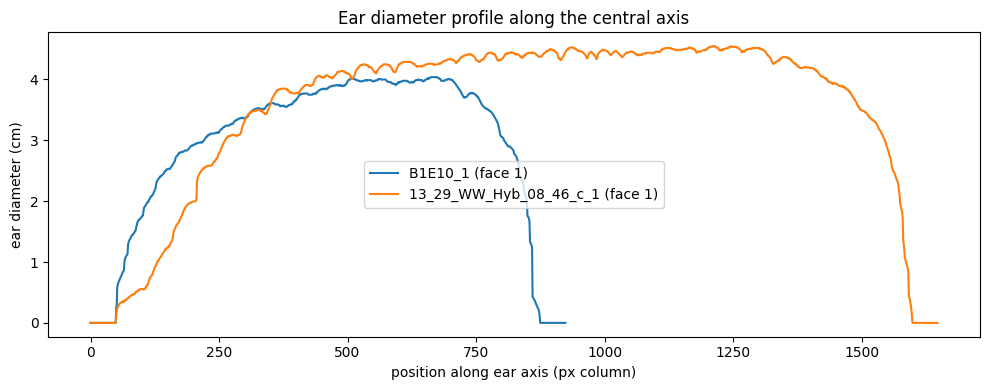

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
ROOTp = "/content/earbox"
script2 = r'''
addpath('/content/earbox/code/analysis/matlab-analyser');
addpath('/content/earbox/code/analysis/matlab-analyser/Utilities');
addpath('/content/earbox/shims');
pkg load image;
EARS = {%s};
for e = 1:numel(EARS)
    obj = FaceEarClass('/content/earbox/data', EARS{e}, 1);
    csvwrite(sprintf('/content/earbox/profile_%%s.csv', EARS{e}), obj.earDiameterProfile);
end
''' % ", ".join("'" + e + "'" for e in ears)
r2 = subprocess.run(["octave", "--no-gui", "--quiet", "--eval", script2], capture_output=True, text=True, timeout=1200)
assert r2.returncode == 0, r2.stderr[-1500:]
fig, ax = plt.subplots(figsize=(10, 4))
for ear in ears:
    prof = np.loadtxt("/content/earbox/profile_%s.csv" % ear, delimiter=",")
    ax.plot(prof * 0.00997, label=ear + " (face 1)")
ax.set_xlabel("position along ear axis (px column)")
ax.set_ylabel("ear diameter (cm)")
ax.legend(); ax.set_title("Ear diameter profile along the central axis")
plt.tight_layout(); plt.savefig("/content/earbox/diameter_profiles.png", dpi=110); plt.show()

## Interpretation and limitations

- The traits above come from the **authors' own MATLAB analysis code**, executed in Octave with the documented shims. Values for `B1E10_1` (a biological-panel ear, length ≈ 8 cm, diameter ≈ 4 cm) fall inside the paper's reported panel ranges (lengths 3–24 cm, diameters 2–5.5 cm), a plausibility check only.
- Per the paper, face-level variables are extrapolations from one imaged side; the authors average 6 faces per ear and validate against manual measurements (ear length R²=0.99 etc.). With 2 sample ears and face 1 only, this notebook is **not** a validation of the paper's dataset-level accuracy.
- The DL2 masks are the authors' shipped reference outputs; re-running CNN segmentation is impossible without the unpublished `.h5` weights.
- `PX2CM` uses the class defaults (0.00996–0.00998 cm/px, constant in the code); the GUI allows custom calibration values which we do not have.

**日本語:** 上記の値は著者コードをOctaveで実行したものです。穂長・直径は論文のパネル範囲内で妥当ですが、2穂・face 1 のみの部分的なデモンストレーションであり、論文のデータセット精度検証ではありません。DL2マスクは著者提供の参照出力です。

**References:** Earbox repo @ `679dc6a4a335f113304e29e0fc0e6c6c29f0dc0d`; Plant Methods 2022;18:96 (PMCID PMC9331584); `analysis/matlab-analyser/@FaceEarClass/FaceEarClass.m`, `Utilities/Calculate_Ears.m`, `ear_masking/writeEarImages.m`, `earbox_variables.md`.
